In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
import shap
import numpy as np
import matplotlib.pyplot as plt

from database_utils import DBManager

from scipy.optimize import minimize
from scipy.special import logsumexp

c:\Users\papin\anaconda3\envs\wavenet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:


# -------------------- Data Preparation --------------------
db_manager = DBManager()
engine = db_manager.connect()

# 1) Read the relevant rows from `trial_results`
df_results = db_manager.read_table("similarity_ratings", engine)

2025-06-19 10:53:55,034 - INFO - All required environment variables are set:
2025-06-19 10:53:55,034 - INFO - DB_HOST: experiment-db.cvqcco2iu49x.ap-southeast-1.rds.amazonaws.com
2025-06-19 10:53:55,035 - INFO - DB_PORT: 3306
2025-06-19 10:53:55,037 - INFO - DB_NAME: experiment
2025-06-19 10:53:55,037 - INFO - DB_USER: admin
2025-06-19 10:53:55,038 - INFO - SQLAlchemy engine created and connected to the database.


In [6]:
df_results

,id,participant_id,sequence_id,trial_index,reference_stimulus,rated_stimulus,rating_value,submitted_at
0,1,1,7,0,679,689,18,2025-06-10 15:09:50
1,2,1,7,0,679,726,46,2025-06-10 15:09:50
2,3,1,7,0,679,739,63,2025-06-10 15:09:50
3,4,1,7,0,679,741,72,2025-06-10 15:09:50
4,5,1,8,3,862,862,100,2025-06-16 12:45:58
...,...,...,...,...,...,...,...,...
499,512,26,8,6,870,873,29,2025-06-18 11:18:51
500,513,26,8,7,878,878,96,2025-06-18 11:20:00
501,514,26,8,7,878,879,42,2025-06-18 11:20:00
502,515,26,8,7,878,880,66,2025-06-18 11:20:00


In [18]:


df_results = df_results[
    (
    (df_results["participant_id"] == 16) |
    # (df_results["participant_id"] == 17) |
    (df_results["participant_id"] == 18) |
    (df_results["participant_id"] == 20) |
    (df_results["participant_id"] == 21) |
    (df_results["participant_id"] == 22) |
    (df_results["participant_id"] == 24) 
    # (df_results["participant_id"] == 26)

    ) &
    (df_results["sequence_id"] == 8)
].copy()


In [9]:
df_results

,id,participant_id,sequence_id,trial_index,reference_stimulus,rated_stimulus,rating_value,submitted_at
248,261,16,8,0,850,850,100,2025-06-17 05:28:48
249,262,16,8,0,850,851,31,2025-06-17 05:28:48
250,263,16,8,0,850,852,89,2025-06-17 05:28:48
251,264,16,8,0,850,853,53,2025-06-17 05:28:48
252,265,16,8,1,854,854,100,2025-06-17 05:29:51
...,...,...,...,...,...,...,...,...
499,512,26,8,6,870,873,29,2025-06-18 11:18:51
500,513,26,8,7,878,878,96,2025-06-18 11:20:00
501,514,26,8,7,878,879,42,2025-06-18 11:20:00
502,515,26,8,7,878,880,66,2025-06-18 11:20:00


In [19]:

df_resource = db_manager.read_table("resources", engine)
# df_resource.rename(columns={"trial": "trial_index", "resource_id": "resource_ids"},inplace=True)
df_resource["resource_id"] = df_resource["id"]

In [11]:
df_resource

,id,filenames,folder_paths,descriptions,resource_id
0,5,D1.wav,resources/piano/D1.wav,File downloaded from public Google Drive folde...,5
1,6,D2.wav,resources/piano/D2.wav,File downloaded from public Google Drive folde...,6
2,7,D3.wav,resources/piano/D3.wav,File downloaded from public Google Drive folde...,7
3,8,D4.wav,resources/piano/D4.wav,File downloaded from public Google Drive folde...,8
4,629,AR_Harmonic 5-Fender deluxe reverb.wav,https://dataset-guitar.s3.ap-southeast-1.amazo...,File mapped to S3 URL from text file,629
...,...,...,...,...,...
395,1066,OrangeRocker30Head_Simulated.wav,https://dataset-guitar.s3.ap-southeast-1.amazo...,S3 file reference (no local download),1066
396,1067,RolandJazzChorus_Reference.wav,https://dataset-guitar.s3.ap-southeast-1.amazo...,S3 file reference (no local download),1067
397,1068,RolandJazzChorus_Simulated.wav,https://dataset-guitar.s3.ap-southeast-1.amazo...,S3 file reference (no local download),1068
398,1069,VOXac30_Reference.wav,https://dataset-guitar.s3.ap-southeast-1.amazo...,S3 file reference (no local download),1069


In [20]:
import pandas as pd
import numpy as np
from scipy.stats import sem          # standard error of the mean

# ── 1)  START FROM YOUR TWO DATA-FRAMES ───────────────────────────────────
# df_results   : trial log (shown in your message)
# df_resources : metadata table with id → filename

# ── 2)  BRING THE FILENAME ONTO EACH RATING ROW ───────────────────────────
df = (
    df_results
    .merge(
        df_resource[['id', 'filenames']],
        left_on='rated_stimulus', right_on='id', how='left'
    )
    .rename(columns={'filenames': 'file'})
    .drop(columns=['id_y'])
)

# ── 3)  MAP EACH ROW TO A “MUSHRA CONDITION” ─────────────────────────────
def map_condition(row):
    if row['rated_stimulus'] == row['reference_stimulus']:
        return 'Reference'                                # ref: rated_id == ref_id
    fname = row['file'] or ''                             # None-safe
    if '_anchor' in fname:
        return 'Anchor'
    if '_new_' in fname:
        return 'New Predicted'
    if '_predicted' in fname:
        return 'Predicted'
    return 'Other'                                        # catch-all (optional)

df['condition'] = df.apply(map_condition, axis=1)

# ── 4)  CALCULATE MUSHRA STATS PER CONDITION ─────────────────────────────
summary = (
    df.groupby('condition')['rating_value']
      .agg(mean='mean', sd='std', n='count')
      .assign(
          se=lambda g: g['sd'] / np.sqrt(g['n'].clip(lower=1)),
          ci_low=lambda g: g['mean'] - 1.96 * g['se'],
          ci_high=lambda g: g['mean'] + 1.96 * g['se']
      )
      .round(2)
      .sort_values('mean', ascending=False)
)

print(summary)


                mean     sd   n    se  ci_low  ci_high
condition                                             
Reference      96.42   5.99  48  0.86   94.72    98.11
New Predicted  60.65  27.19  48  3.92   52.95    68.34
Predicted      55.73  23.45  48  3.38   49.09    62.36
Anchor         36.85  27.77  48  4.01   29.00    44.71


In [21]:
import pandas as pd
import numpy as np

# ── STEP 1: MERGE FILE NAMES ─────────────────────────────────────────────
df = (
    df_results
    .merge(
        df_resource[['id', 'filenames']],
        left_on='rated_stimulus', right_on='id', how='left'
    )
    .rename(columns={'filenames': 'file'})
    .drop(columns=['id_y'])
)

# ── STEP 2: MAP CONDITIONS ───────────────────────────────────────────────
def map_condition(row):
    if row['rated_stimulus'] == row['reference_stimulus']:
        return 'Reference'
    fname = row['file'] or ''
    if '_anchor' in fname:
        return 'Anchor'
    if '_new_' in fname:
        return 'New Predicted'
    if '_predicted' in fname:
        return 'Predicted'
    return 'Other'

df['condition'] = df.apply(map_condition, axis=1)

# ── STEP 3: NORMALIZE PER PARTICIPANT ─────────────────────────────────────
def normalize_per_subject(g):
    anchor = g.loc[g['condition'] == 'Anchor', 'rating_value'].mean()
    reference = g.loc[g['condition'] == 'Reference', 'rating_value'].mean()
    denom = reference - anchor
    if pd.isna(denom) or denom == 0:
        g['normalized'] = np.nan
    else:
        g['normalized'] = (g['rating_value'] - anchor) / denom
    return g

df_normalized = (
    df.groupby('participant_id')
      .apply(normalize_per_subject)
      .reset_index(drop=True)
)

# ── STEP 4: SUMMARY ACROSS PARTICIPANTS (MEAN OF NORMALIZED RATINGS) ────
summary_normalized = (
    df_normalized.groupby('condition')['normalized']
    .agg(mean='mean', sd='std', n='count')
    .assign(
        se=lambda g: g['sd'] / np.sqrt(g['n'].clip(lower=1)),
        ci_low=lambda g: g['mean'] - 1.96 * g['se'],
        ci_high=lambda g: g['mean'] + 1.96 * g['se']
    )
    .round(3)
    .sort_values('mean', ascending=False)
)

print(summary_normalized)

                mean     sd   n     se  ci_low  ci_high
condition                                              
Reference      1.000  0.043  48  0.006   0.988    1.012
New Predicted  0.373  0.432  48  0.062   0.251    0.495
Predicted      0.282  0.384  48  0.055   0.173    0.390
Anchor         0.000  0.356  48  0.051  -0.101    0.101


C:\Users\papin\AppData\Local\Temp\ipykernel_12364\3480283800.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(normalize_per_subject)


In [17]:
# Group by participant and condition
intra_per_participant = (
    df.groupby(['participant_id', 'condition'])['rating_value']
    .agg(mean='mean', sd='std', n='count')
    .assign(
        se=lambda g: g['sd'] / np.sqrt(g['n'].clip(lower=1)),
        ci_low=lambda g: g['mean'] - 1.96 * g['se'],
        ci_high=lambda g: g['mean'] + 1.96 * g['se']
    )
    .round(2)
)

# Optional: display for each participant
for pid in intra_per_participant.index.get_level_values(0).unique():
    print(f"\n▶ Participant {pid}")
    print(intra_per_participant.loc[pid])


▶ Participant 16
                 mean     sd  n    se  ci_low  ci_high
condition                                             
Anchor          63.00  22.53  8  7.96   47.39    78.61
New Predicted   68.25  18.37  8  6.49   55.52    80.98
Predicted       60.12  17.33  8  6.13   48.11    72.14
Reference      100.00   0.00  8  0.00  100.00   100.00

▶ Participant 17
                mean     sd  n    se  ci_low  ci_high
condition                                            
Anchor         35.12  26.97  8  9.54   16.43    53.82
New Predicted  53.88  25.35  8  8.96   36.31    71.44
Predicted      48.62  25.59  8  9.05   30.89    66.36
Reference      80.12   9.92  8  3.51   73.25    87.00

▶ Participant 18
                mean     sd  n     se  ci_low  ci_high
condition                                             
Anchor          0.00   0.00  8   0.00    0.00     0.00
New Predicted  40.00  41.40  8  14.64   11.31    68.69
Predicted      30.00  33.38  8  11.80    6.87    53.13
Reference      95

In [11]:
import pandas as pd
import numpy as np

# ── STEP 1: START WITH CLEANED & MAPPED DATA ─────────────────────────────
df = (
    df_results
    .merge(
        df_resource[['id', 'filenames']],
        left_on='rated_stimulus', right_on='id', how='left'
    )
    .rename(columns={'filenames': 'file'})
    .drop(columns=['id_y'])
)

def map_condition(row):
    if row['rated_stimulus'] == row['reference_stimulus']:
        return 'Reference'
    fname = row['file'] or ''
    if '_anchor' in fname:
        return 'Anchor'
    if '_new_' in fname:
        return 'New Predicted'
    if '_predicted' in fname:
        return 'Predicted'
    return 'Other'

df['condition'] = df.apply(map_condition, axis=1)

# ── STEP 2: INTER-SUBJECT STATS (mean rating per participant) ─────────────
df_participant_mean = (
    df.groupby(['participant_id', 'condition'])['rating_value']
      .mean()
      .reset_index()
)

inter_subject_summary = (
    df_participant_mean
    .groupby('condition')['rating_value']
    .agg(mean='mean', sd='std', n='count')
    .assign(
        se=lambda g: g['sd'] / np.sqrt(g['n'].clip(lower=1)),
        ci_low=lambda g: g['mean'] - 1.96 * g['se'],
        ci_high=lambda g: g['mean'] + 1.96 * g['se']
    )
    .round(2)
    .sort_values('mean', ascending=False)
)

# ── STEP 3: INTRA-SUBJECT STATS (within-subject std per condition) ───────
df_intra = (
    df.groupby(['participant_id', 'condition'])['rating_value']
      .std()
      .reset_index()
      .dropna()
)

intra_subject_summary = (
    df_intra
    .groupby('condition')['rating_value']
    .agg(mean_sd='mean', sd_sd='std', n='count')
    .assign(
        se=lambda g: g['sd_sd'] / np.sqrt(g['n'].clip(lower=1)),
        ci_low=lambda g: g['mean_sd'] - 1.96 * g['se'],
        ci_high=lambda g: g['mean_sd'] + 1.96 * g['se']
    )
    .round(2)
    .sort_values('mean_sd', ascending=True)
)

# ── STEP 4: OUTPUT ───────────────────────────────────────────────────────
print("\nINTER-SUBJECT SUMMARY (mean across participants):")
print(inter_subject_summary)

print("\nINTRA-SUBJECT SUMMARY (within-subject std):")
print(intra_subject_summary)


INTER-SUBJECT SUMMARY (mean across participants):
                mean     sd  n    se  ci_low  ci_high
condition                                            
Reference      93.73   7.31  8  2.59   88.67    98.80
New Predicted  58.36  11.27  8  3.99   50.55    66.17
Predicted      53.61  12.67  8  4.48   44.83    62.39
Anchor         37.39  20.86  8  7.37   22.94    51.84

INTRA-SUBJECT SUMMARY (within-subject std):
               mean_sd  sd_sd  n    se  ci_low  ci_high
condition                                              
Reference         4.23   4.17  8  1.47    1.35     7.12
Anchor           15.58   9.62  8  3.40    8.91    22.25
Predicted        19.23   8.06  8  2.85   13.64    24.81
New Predicted    23.63   9.28  8  3.28   17.19    30.06


In [16]:
import pandas as pd
import numpy as np

# ── STEP 1: MERGE AND MAP CONDITIONS ─────────────────────────────────────
df = (
    df_results
    .merge(
        df_resource[['id', 'filenames']],
        left_on='rated_stimulus', right_on='id', how='left'
    )
    .rename(columns={'filenames': 'file'})
    .drop(columns=['id_y'])
)

def map_condition(row):
    if row['rated_stimulus'] == row['reference_stimulus']:
        return 'Reference'
    fname = row['file'] or ''
    if '_anchor' in fname:
        return 'Anchor'
    if '_new_' in fname:
        return 'New Predicted'
    if '_predicted' in fname:
        return 'Predicted'
    return 'Other'

df['condition'] = df.apply(map_condition, axis=1)

# ── STEP 2: FILTER VALID PARTICIPANTS (Reference ≥ 95) ───────────────────
mean_ref = (
    df[df['condition'] == 'Reference']
    .groupby('participant_id')['rating_value']
    .mean()
    .reset_index()
    .rename(columns={'rating_value': 'mean_ref'})
)

valid_participants = mean_ref[mean_ref['mean_ref'] >= 95]['participant_id']
df_valid = df[df['participant_id'].isin(valid_participants)].copy()

# ── STEP 3: NORMALIZE RATINGS PER PARTICIPANT ────────────────────────────
def normalize_group(g):
    anchor = g.loc[g['condition'] == 'Anchor', 'rating_value'].mean()
    reference = g.loc[g['condition'] == 'Reference', 'rating_value'].mean()
    g['norm_rating'] = (g['rating_value'] - anchor) / (reference - anchor) if (reference - anchor) != 0 else np.nan
    return g

df_normalized = (
    df_valid.groupby('participant_id')
    .apply(normalize_group)
    .reset_index(drop=True)
    .dropna(subset=['norm_rating'])
)

# ── STEP 4: PRINT INTRA-SUBJECT NORMALIZED RATINGS ───────────────────────
print("\nINTRA-SUBJECT NORMALIZED SCORES (per participant_id × condition):")
intra_summary = (
    df_normalized
    .groupby(['participant_id', 'condition'])['norm_rating']
    .mean()
    .unstack()
    .round(2)
)
print(intra_summary)

# ── STEP 5: INTER-SUBJECT SUMMARY ────────────────────────────────────────
inter_summary = (
    df_normalized
    .groupby('condition')['norm_rating']
    .agg(mean='mean', sd='std', n='count')
    .assign(
        se=lambda g: g['sd'] / np.sqrt(g['n'].clip(lower=1)),
        ci_low=lambda g: g['mean'] - 1.96 * g['se'],
        ci_high=lambda g: g['mean'] + 1.96 * g['se']
    )
    .round(3)
    .sort_values('mean', ascending=False)
)

print("\nINTER-SUBJECT SUMMARY (normalized):")
print(inter_summary)


INTRA-SUBJECT NORMALIZED SCORES (per participant_id × condition):
condition       Anchor  New Predicted  Predicted  Reference
participant_id                                             
16                 0.0           0.14      -0.08        1.0
18                 0.0           0.42       0.31        1.0
20                -0.0           0.35       0.29        1.0
22                 0.0           0.30       0.20        1.0
24                 0.0           0.46       0.42        1.0

INTER-SUBJECT SUMMARY (normalized):
                mean     sd   n     se  ci_low  ci_high
condition                                              
Reference      1.000  0.042  40  0.007   0.987    1.013
New Predicted  0.334  0.458  40  0.072   0.192    0.475
Predicted      0.229  0.398  40  0.063   0.106    0.353
Anchor         0.000  0.390  40  0.062  -0.121    0.121


C:\Users\papin\AppData\Local\Temp\ipykernel_12364\1412417944.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(normalize_group)


In [ ]:

# optional: categorise each clip (reference, anchor, model, …)
def label_condition(fname: str) -> str:
    if '_anchor'     in fname: return 'Anchor'
    if '_new_'       in fname: return 'New Predicted'
    if '_predicted'  in fname: return 'Predicted'
    return 'Reference'

df['condition'] = df['file'].apply(label_condition)

# ── 2)  BASIC MUSHRA STATS PER CONDITION ──────────────────────────────────
stats = (
    df
    .groupby('condition')['rating_value']
    .agg(
        mean   = 'mean',
        sd     = 'std',
        n      = 'count',
    )
    .assign(
        se = lambda d: sem(df.loc[df['condition'].isin(d.index), 'rating_value'],
                           nan_policy='omit', axis=None), # vectorised SE
        ci_low  = lambda d: d['mean'] - 1.96 * d['se'],
        ci_high = lambda d: d['mean'] + 1.96 * d['se'],
    )
    .round(2)
    .reset_index()
    .sort_values('mean', ascending=False)
)

print(stats)


In [ ]:


# List of known amp names
amp_names = [
    "Marshall 1959Plexi",
    "Fender deluxe reverb",
    "VOXac30 custom",
    "Plugin_GTR Amp",
    "Roland Jazz Chorus",
    "Marshall JCM800",
    "Marshall 1959Plexi",
    "Orange Rocker30 Head"
]

def extract_amp_hardcoded(text):
    for amp in amp_names:
        if amp in text:
            return amp
    print(f"Unknown amp in text: {text}")
    return None  # or 'Unknown'

df_merged_features['amp'] = df_merged_features['filenames'].apply(extract_amp_hardcoded)



print(df_merged_features[['resource_id', 'amp','final_score', 'rank_position']])

# Plotting
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_merged_features['rank_position'], df_merged_features['final_score'], c=pd.factorize(df_merged_features['amp'])[0], cmap='tab10', label=df_merged_features['amp'])
plt.xlabel('Rank Position')
plt.ylabel('Final Score')
plt.title('Final Score vs. Rank by Amp')
plt.grid(True)

# Creating a legend with amp names
handles, _ = scatter.legend_elements(prop="colors")
unique_amps = pd.unique(df_merged_features['amp'])
plt.legend(handles, unique_amps, title="Amp", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
df_merged_features.boxplot(column='final_score', by='amp', grid=False)
plt.title('Distribution of Final Score by Amp')
plt.suptitle('')
plt.xlabel('Amp')
plt.ylabel('Final Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# -----------------

In [8]:
#--- Modeling --------------------
# Define feature columns and target variable
feature_columns = ["spectral_centroid_med", "spectral_centroid_iqr", 
                   "spectral_bandwidth_iqr", "f0", "hnr_med"]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

X = df_merged_features[feature_columns]
y = df_merged_features["final_score"]/df_merged_features["final_score"].max()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
len(y_train), len(y_test)

(140, 35)

In [10]:
max(y_train)

1.0

In [11]:
min(y_train)

0.22301151016976262

In [ ]:
may be linear regression is better here?

Fold 1: MSE: 0.0164, RMSE: 0.1279, MAE: 0.0999
Fold 2: MSE: 0.0236, RMSE: 0.1536, MAE: 0.1134
Fold 3: MSE: 0.0243, RMSE: 0.1560, MAE: 0.1148
Fold 4: MSE: 0.0267, RMSE: 0.1634, MAE: 0.1281
Fold 5: MSE: 0.0401, RMSE: 0.2003, MAE: 0.1571
min:  0.22301151016976262  max:  1.0

Final Model Metrics on Test Set:
MSE: 0.0293, RMSE: 0.1710, MAE: 0.1348


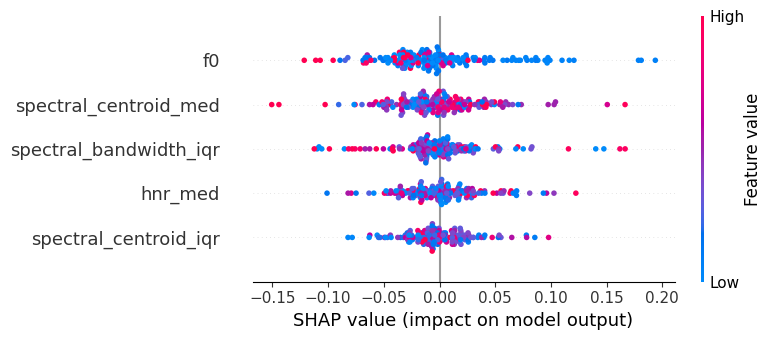

In [12]:
# import linear_model
from sklearn.linear_model import LinearRegression

# --- 5-Fold Cross Validation ---
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_metrics = []
fold = 1

for train_index, val_index in kfold.split(X_train):
    X_train_cv, X_val_cv = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_cv, y_val_cv = y_train.iloc[train_index], y_train.iloc[val_index]

    model_cv = LinearRegression()
    model_cv.fit(X_train_cv, y_train_cv)

    y_pred_val = model_cv.predict(X_val_cv)

    mse = mean_squared_error(y_val_cv, y_pred_val)
    mae = mean_absolute_error(y_val_cv, y_pred_val)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val_cv, y_pred_val)

    fold_metrics.append({
        'fold': fold,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

    print(f"Fold {fold}: MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    fold += 1


plt.plot(y_test.sort_values(ascending=False).values)



# 3. Train final model on all training data
final_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, learning_rate=0.1,n_estimators=10000)
final_model.fit(X_train, y_train)

print("min: ", min(y_train)," max: ", max(y_train))

# 4. Evaluate on the hold-out test set
y_pred_test = final_model.predict(X_test)

# plt.plot(y_pred_test.sort_values(ascending=False).values)
# plt.title("Final Scores")
# plt.show()
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print("\nFinal Model Metrics on Test Set:")
print(f"MSE: {mse_test:.4f}, RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}")

# # SHAP Explanation (on test set or full train set)
explainer = shap.Explainer(final_model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)



Fold 1: MSE: 0.0288, RMSE: 0.1697, MAE: 0.1211
Fold 2: MSE: 0.0295, RMSE: 0.1718, MAE: 0.1378
Fold 3: MSE: 0.0306, RMSE: 0.1750, MAE: 0.1333
Fold 4: MSE: 0.0288, RMSE: 0.1696, MAE: 0.1505
Fold 5: MSE: 0.0514, RMSE: 0.2267, MAE: 0.1764
min:  0.042800333223691825  max:  1.0

Final Model Metrics on Test Set:
MSE: 0.0246, RMSE: 0.1567, MAE: 0.1258


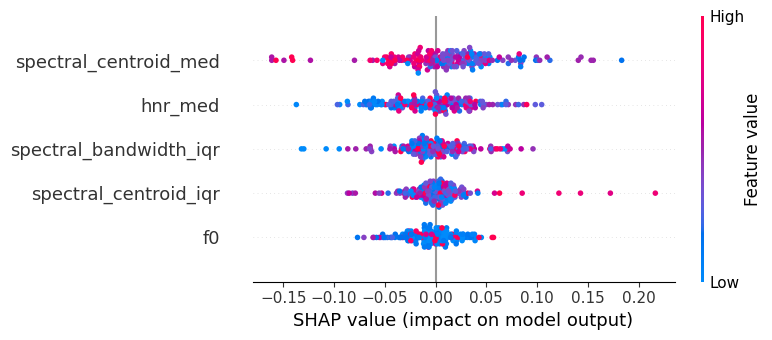

In [9]:
# --- 5-Fold Cross Validation ---
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_metrics = []
fold = 1

for train_index, val_index in kfold.split(X_train):
    X_train_cv, X_val_cv = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_cv, y_val_cv = y_train.iloc[train_index], y_train.iloc[val_index]

    model_cv = xgb.XGBRegressor(objective='reg:squarederror', random_state=42,learning_rate=0.1)
    model_cv.fit(X_train_cv, y_train_cv)

    y_pred_val = model_cv.predict(X_val_cv)

    mse = mean_squared_error(y_val_cv, y_pred_val)
    mae = mean_absolute_error(y_val_cv, y_pred_val)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val_cv, y_pred_val)

    fold_metrics.append({
        'fold': fold,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

    print(f"Fold {fold}: MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    fold += 1


plt.plot(y_test.sort_values(ascending=False).values)



# 3. Train final model on all training data
final_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, learning_rate=0.1,n_estimators=10000)
final_model.fit(X_train, y_train)

print("min: ", min(y_train)," max: ", max(y_train))

# 4. Evaluate on the hold-out test set
y_pred_test = final_model.predict(X_test)

# plt.plot(y_pred_test.sort_values(ascending=False).values)
# plt.title("Final Scores")
# plt.show()
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print("\nFinal Model Metrics on Test Set:")
print(f"MSE: {mse_test:.4f}, RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}")

# # SHAP Explanation (on test set or full train set)
explainer = shap.Explainer(final_model)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)



In [14]:
import numpy as np
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, explained_variance_score)

# y_test, y_test_pred: 1-D NumPy arrays or Pandas Series
mae  = mean_absolute_error(y_test.to_numpy(), y_pred_test)
mse  = mean_squared_error(y_test.to_numpy(), y_pred_test)
rmse = np.sqrt(mse)
r2   = r2_score(y_test.to_numpy(), y_pred_test)
evs  = explained_variance_score(y_test.to_numpy(), y_pred_test)

print(f"MAE  : {mae:,.4f}")
print(f"RMSE : {rmse:,.4f}")
print(f"R²   : {r2:,.4f}")
print(f"Explained variance: {evs:,.4f}")


MAE  : 0.1348
RMSE : 0.1710
R²   : -0.5896
Explained variance: -0.4984


In [15]:
y_mean = np.full_like(y_test, 0.5)
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_mean)))


Baseline RMSE: 0.14371751627924104


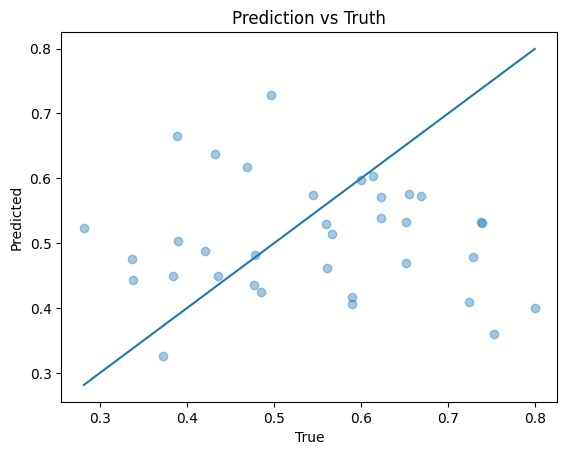

In [16]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("True"); plt.ylabel("Predicted"); plt.title("Prediction vs Truth"); plt.show()


In [18]:
df_data = pd.concat([X, y], axis=1).sort_values(by="final_score", ascending=False)

In [19]:
df_data.to_csv("final_scores_with_features.csv", index=False)

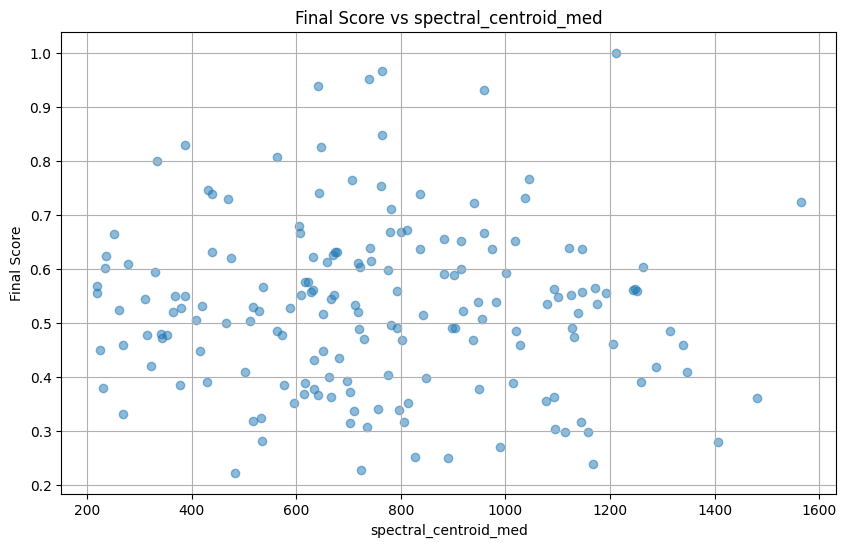

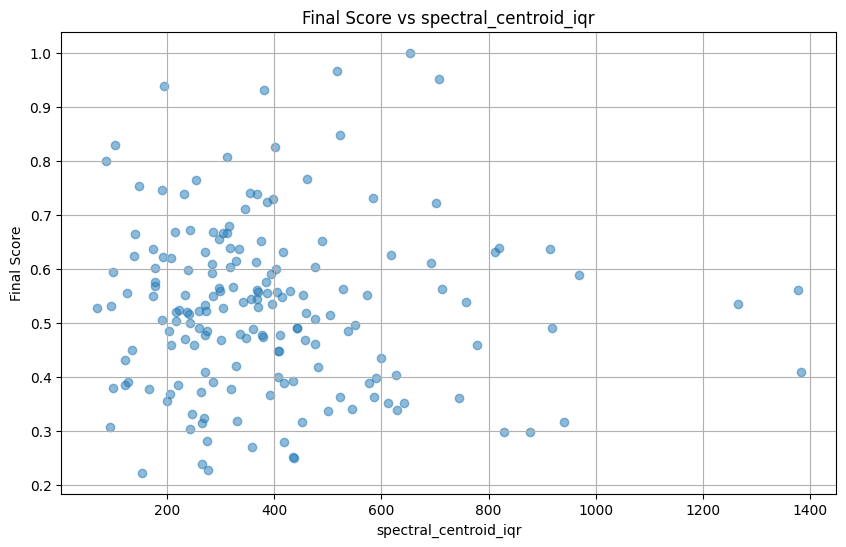

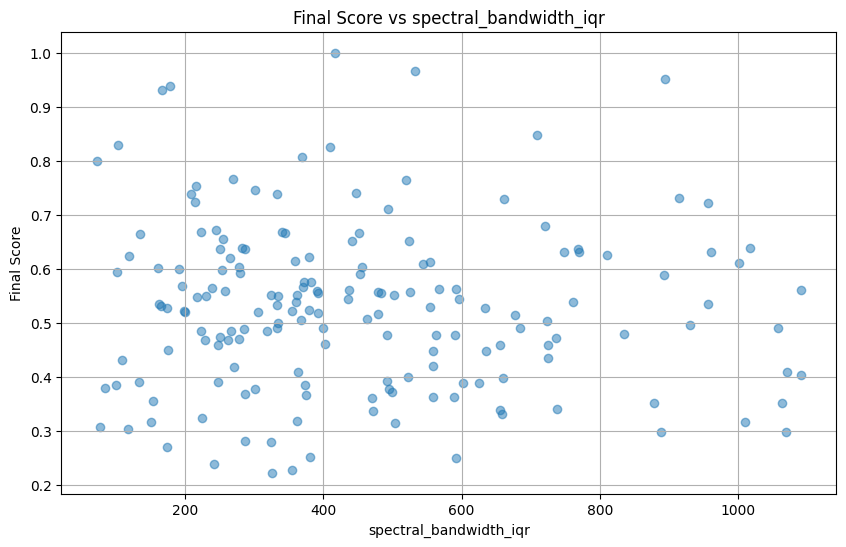

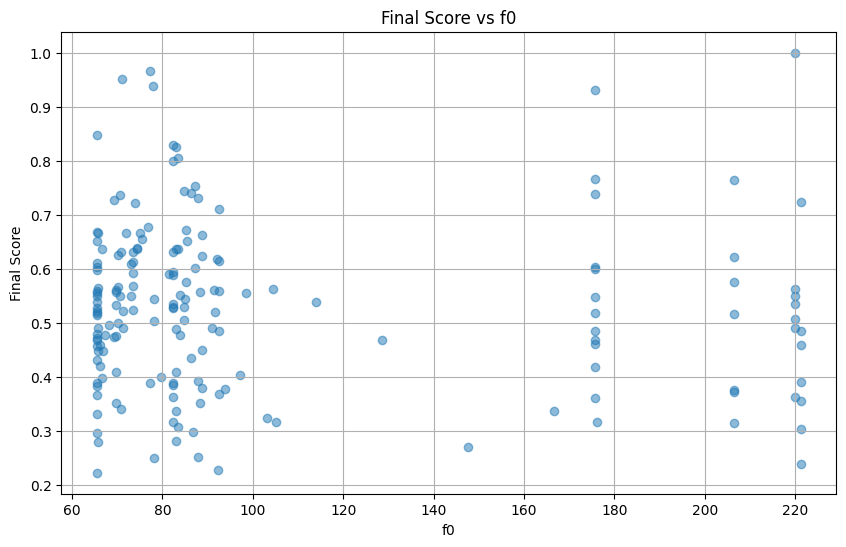

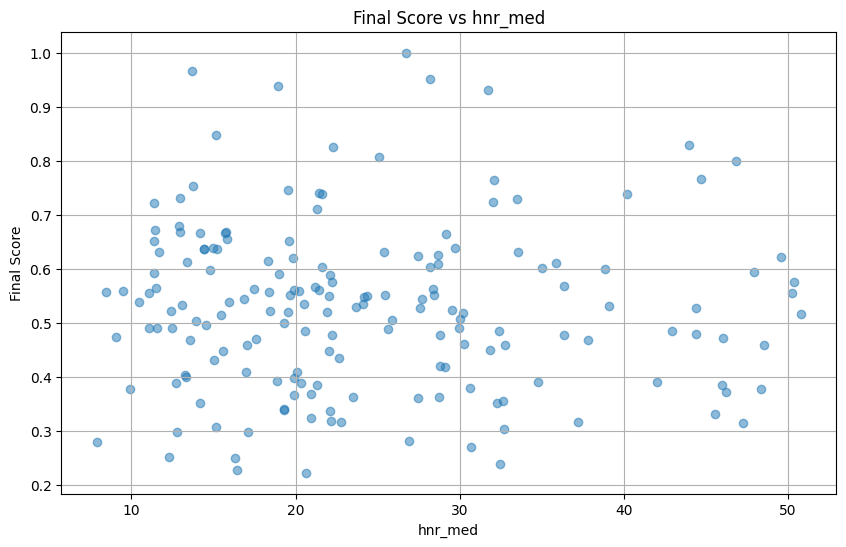

In [20]:
for col in feature_columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df_data[col], df_data["final_score"], alpha=0.5)
    plt.title(f"Final Score vs {col}")
    plt.xlabel(col)
    plt.ylabel("Final Score")
    plt.grid(True)
    plt.show()